# Week 3 · Demo 2 — Text Classification: Frozen Features vs Fine-Tuning

Demo 1 used models that were trained on *someone else's* task. Here we make one our own:
an **emotion detector** over English tweets, built on DistilBERT — BERT compressed to
6 layers / ~66M parameters so it trains in minutes (on the demo Mac's MPS backend; on a
Colab T4, faster still).

The road map, which is also the week's storyline:

| Section | What we do | The idea |
|---|---|---|
| 1. The dataset | load & explore `emotion` from the Hub | "become one with the data" |
| 2. Text → tokens | char / word / **subword** tokenization | why `[CLS] ##izing` exists |
| 3. Feature extraction | frozen DistilBERT → hidden states → logistic regression | embeddings without training |
| 4. Fine-tuning | swap the head, train end-to-end with `Trainer` | backprop through everything |
| 5. Error analysis | sort validation set by loss | find mislabeled data |
| 6. Inference | save the model, run it locally with `pipeline` | the deliverable |

> **Environment note.** `transformers` v5, `datasets` 5.x. Two v5 APIs differ from the
> book: `TrainingArguments(eval_strategy=...)` (was `evaluation_strategy`) and
> `Trainer(processing_class=...)` (was `tokenizer=`). Everything runs on
> CPU / Apple-silicon MPS / CUDA — the device is auto-detected below.
> End-to-end runtime: **~15–20 min** on an M-series Mac, most of it training.

## 1 · The dataset

`emotion` (Saravia et al., *CARER*, EMNLP 2018) contains English Twitter messages
labeled with six basic emotions: **sadness, joy, love, anger, fear, surprise** — a
6-class problem, not the binary sentiment of Demo 1.

First, a feel for the Hub: `list_datasets` (note — it lives in `huggingface_hub`, it
left the `datasets` library in v3). The Hub hosts **over a million datasets**; we pull
the 100 most trending rather than enumerate them all (a full listing is ~2M rows over
the wire and takes minutes).

In [ ]:
from huggingface_hub import list_datasets

all_datasets = [d.id for d in list_datasets(limit=100)]
print(f"There are over 1 million datasets on the Hub — showing the {len(all_datasets)} most trending")
print(f"The first 10 are: {all_datasets[:10]}")

There are over 1 million datasets on the Hub — showing the 100 most trending
The first 10 are: ['nyu-mll/glue', 'stanfordnlp/imdb', 'rajpurkar/squad', 'openbmb/UltraData-SFT-Agent-2609', 'openbmb/UltraData-RL-2609', 'openbmb/UltraData-Code', 'markov-ai/cad-1000-hours', 'MoreThought/Fable-5.1-Max-Reasoning-Filtered-5000x', 'wikimedia/wikipedia', 'Yootta/World-SimReady-Home']


Now load the dataset. Two practical notes:

- The canonical id is **`dair-ai/emotion`**. The old book id `"emotion"` no longer
  resolves on `datasets` ≥ 3 (script-based loading was removed), so use the parquet
  version.
- `load_dataset` downloads once, then serves from the local cache
  (`~/.cache/huggingface/datasets/`).

In [ ]:
from datasets import load_dataset

emotions = load_dataset("dair-ai/emotion")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

A `DatasetDict` is dict-like: one key per split. **Do your model selection on
`validation`, touch `test` exactly once at the end.**

In [ ]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [ ]:
train_ds = emotions["train"]
train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

It behaves like a list (`len`, indexing) and like a dict (column names) at the same time:

In [ ]:
len(train_ds)

16000

In [ ]:
train_ds[0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [ ]:
train_ds.column_names

['text', 'label']

The interesting part is `features`: `datasets` is built on **Apache Arrow** (typed,
columnar, memory-mapped), and the `label` column is a `ClassLabel` — it carries the
int ↔ emotion-name mapping, so we never have to maintain our own label dictionary.

In [ ]:
print(train_ds.features)

{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}


In [ ]:
print(train_ds[:5])

{'text': ['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy'], 'label': [0, 0, 3, 2, 3]}


In [ ]:
print(train_ds["text"][:5])

['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy']


### From Dataset to DataFrame

For plotting we switch the *output format* to pandas. Note this does **not** convert
the underlying data — it's still an Arrow table on disk; only what indexing returns
changes. Then decode labels with the `ClassLabel`'s own `int2str`:

In [ ]:
import pandas as pd

emotions.set_format(type="pandas")
df = emotions["train"][:]
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [ ]:
def label_int2str(row):
    return emotions["train"].features["label"].int2str(row)

df["label_name"] = df["label"].apply(label_int2str)
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


### Sanity check 1 — class distribution

Karpathy's rule: become one with the data before training on it. First question for any
classifier: **how balanced are the classes?**

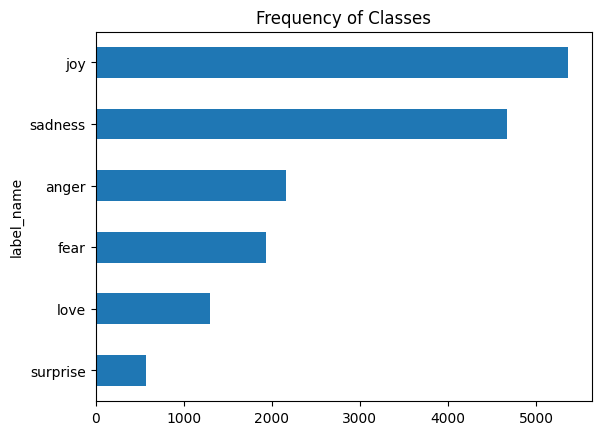

In [ ]:
import matplotlib.pyplot as plt

df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.show()

Heavily imbalanced: `joy` and `sadness` dominate; `love` and `surprise` are ~5–10×
rarer. Consequence: **accuracy is a misleading metric here** — always-predict-`sadness`
scores ~33% while learning nothing. That's why we'll report weighted F1 and compare
against a dummy baseline. (Fixes — over/undersampling, class weights — exist, but we
keep the raw frequencies and note the bias.)

### Sanity check 2 — how long are the tweets?

Transformers have a **maximum context size** (DistilBERT: 512 tokens). Longer inputs
get truncated — losing the end of the text. Distribution check before we commit:

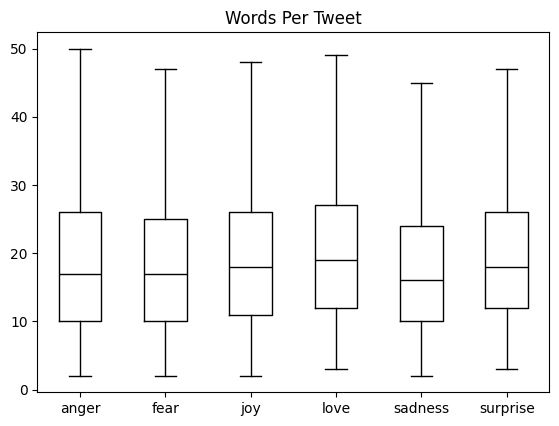

In [ ]:
df["Words Per Tweet"] = df["text"].str.split().apply(len)
df.boxplot("Words Per Tweet", by="label_name", grid=False, showfliers=False,
           color="black")
plt.suptitle("")
plt.xlabel("")
plt.show()

~15 words typical, max ≈ 70 — nowhere near 512, so truncation is a non-issue here.
(Every dataset gets this check; most real documents don't pass it.)

Done with pandas — reset the format so the dataset returns Arrow/Python types again:

In [ ]:
emotions.reset_format()

## 2 · From text to tokens

The model cannot read strings — it consumes **token IDs**. Tokenization decides what
the atomic units are, and the strategy is a real trade-off. We'll build up to the
subword scheme DistilBERT uses by trying the two extremes on a toy sentence.

### Extreme 1: character tokenization

Split into characters, then numbericalize: give every distinct character an integer ID.

In [ ]:
text = "Tokenizing text is a core task of NLP."
tokenized_text = list(text)
print(tokenized_text)

['T', 'o', 'k', 'e', 'n', 'i', 'z', 'i', 'n', 'g', ' ', 't', 'e', 'x', 't', ' ', 'i', 's', ' ', 'a', ' ', 'c', 'o', 'r', 'e', ' ', 't', 'a', 's', 'k', ' ', 'o', 'f', ' ', 'N', 'L', 'P', '.']


In [ ]:
token2idx = {ch: idx for idx, ch in enumerate(sorted(set(tokenized_text)))}
print(token2idx)

{' ': 0, '.': 1, 'L': 2, 'N': 3, 'P': 4, 'T': 5, 'a': 6, 'c': 7, 'e': 8, 'f': 9, 'g': 10, 'i': 11, 'k': 12, 'n': 13, 'o': 14, 'r': 15, 's': 16, 't': 17, 'x': 18, 'z': 19}


In [ ]:
input_ids = [token2idx[token] for token in tokenized_text]
print(input_ids)

[5, 14, 12, 8, 13, 11, 19, 11, 13, 10, 0, 17, 8, 18, 17, 0, 11, 16, 0, 6, 0, 7, 14, 15, 8, 0, 17, 6, 16, 12, 0, 14, 9, 0, 3, 2, 4, 1]


Problem: integer IDs imply an **ordinal scale** (`token2idx["c"]=3` minus
`token2idx["a"]=1`… meaningless). The standard fix for categorical values is one-hot
encoding. Same issue if we one-hot-encode names — integer IDs would invent an ordering:

In [ ]:
categorical_df = pd.DataFrame(
    {"Name": ["Bumblebee", "Optimus Prime", "Megatron"], "Label ID": [0,1,2]})
categorical_df

,Name,Label ID
0,Bumblebee,0
1,Optimus Prime,1
2,Megatron,2


In [ ]:
pd.get_dummies(categorical_df["Name"])

,Bumblebee,Megatron,Optimus Prime
0,True,False,False
1,False,False,True
2,False,True,False


In [ ]:
import torch
import torch.nn.functional as F

input_ids = torch.tensor(input_ids)
one_hot_encodings = F.one_hot(input_ids, num_classes=len(token2idx))
one_hot_encodings.shape

torch.Size([38, 20])

Verify the encoding is faithful — vector for token 0 should be hot at position 0:

In [ ]:
print(f"Token: {tokenized_text[0]}")
print(f"Tensor index: {input_ids[0]}")
print(f"One-hot: {one_hot_encodings[0]}")

Token: T
Tensor index: 5
One-hot: tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


Character tokenization: no OOV problem, but the model must **learn words from
characters** — huge sequences, huge compute, rarely used in practice.

### Extreme 2: word tokenization

Split on whitespace instead — words carry structure for free:

In [ ]:
tokenized_text = text.split()
print(tokenized_text)

['Tokenizing', 'text', 'is', 'a', 'core', 'task', 'of', 'NLP.']


Better — but look: `NLP.` kept its punctuation, and the vocabulary would explode with
every conjugation, plural, and typo (easily millions of entries; the embedding matrix
alone would be billions of parameters). Capping the vocab maps rare words to `UNK`,
throwing information away.

### The compromise: subword tokenization

What pretrained models actually use — **WordPiece** in DistilBERT's case. Frequent
words stay whole; rare words split into meaningful pieces (`##` marks a piece that
attaches to the previous one). Learned from the pretraining corpus, and crucially:
**always use the tokenizer the checkpoint was trained with** — swapping it is like
shuffling the model's dictionary.

In [ ]:
from transformers import AutoTokenizer

model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

`AutoTokenizer.from_pretrained` reads the checkpoint's config and loads the matching
tokenizer class from the Hub (cached after first download). Now encode the toy text:

In [ ]:
encoded_text = tokenizer(text)
print(encoded_text)

{'input_ids': [101, 19204, 6026, 3793, 2003, 1037, 4563, 4708, 1997, 17953, 2361, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


`input_ids` again — but decode them back to *tokens* (not the string yet) to see the
splitting:

In [ ]:
tokens = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)
print(tokens)

['[CLS]', 'token', '##izing', 'text', 'is', 'a', 'core', 'task', 'of', 'nl', '##p', '.', '[SEP]']


Three things to observe:

1. **`[CLS]` and `[SEP]`** bookend the sequence — `[CLS]`'s final hidden state becomes
   the pooled sentence representation that classification heads consume (Demo 1, task 1).
2. Everything is **lowercased** — that's the `uncased` in the checkpoint name.
3. `##izing` / `##p`: the `##` prefix means "glue me to the previous token, no
   whitespace". Round-trip check:

In [ ]:
print(tokenizer.convert_tokens_to_string(tokens))

[CLS] tokenizing text is a core task of nlp. [SEP]


Three numbers worth memorizing for any tokenizer — vocabulary size, context limit,
and the forward-pass field names:

In [ ]:
tokenizer.vocab_size

30522

In [ ]:
tokenizer.model_max_length

512

In [ ]:
tokenizer.model_input_names

['input_ids', 'token_type_ids', 'attention_mask']

### Tokenizing the whole dataset

The real loop — one function, `padding=True` (pad to longest in batch),
`truncation=True` (cut at 512). Try it on two tweets:

In [ ]:
def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

In [ ]:
print(tokenize(emotions["train"][:2]))

{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


The `attention_mask` is the twin of padding: 1 for real tokens, 0 for `[PAD]` so
attention skips them.

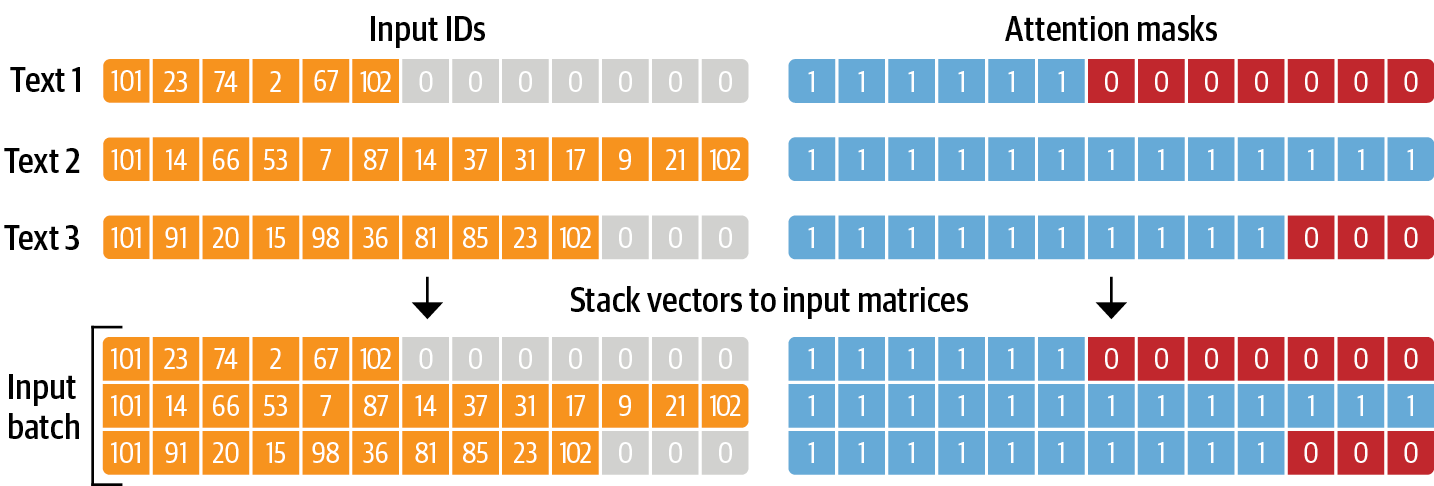

The special tokens, for the record:

In [ ]:
tokens2ids = list(zip(tokenizer.all_special_tokens, tokenizer.all_special_ids))
data = sorted(tokens2ids, key=lambda x : x[-1])
df = pd.DataFrame(data, columns=["Special Token", "Special Token ID"])
df.T

,0,1,2,3,4
Special Token,[PAD],[UNK],[CLS],[SEP],[MASK]
Special Token ID,0,100,101,102,103


Now `map()` it across **all splits in one line**. With `batched=True,
batch_size=None` the whole split is one batch, so padding is *global* — every tweet
padded to the longest tweet in the corpus. Wasteful in production (data collators pad
per batch instead), convenient for the feature extraction we're about to do:

In [ ]:
emotions_encoded = emotions.map(tokenize, batched=True, batch_size=None)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
print(emotions_encoded["train"].column_names)

['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']


## 3 · Transformer as feature extractor (no training)

Two ways to classify with a pretrained encoder:

- **Feature extraction** — freeze the body, use its hidden states as features, train a
  cheap classical classifier on top. No GPU needed, precompute once.
- **Fine-tuning** — train the head *and* the body end-to-end. Better accuracy, needs
  gradients through 66M parameters.

We do both, starting with features. Load DistilBERT **without** any task head —
`AutoModel` returns hidden states, nothing else — and park it on the best available
device (CUDA → Apple MPS → CPU):

In [ ]:
from transformers import AutoModel

model_ckpt = "distilbert-base-uncased"

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")

model = AutoModel.from_pretrained(model_ckpt).to(device)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Warm-up on one string. Encode to tensors and check the shape —
`[batch_size, n_tokens]`:

In [ ]:
text = "this is a test"
inputs = tokenizer(text, return_tensors="pt")
print(f"Input tensor shape: {inputs['input_ids'].size()}")

Input tensor shape: torch.Size([1, 6])


`torch.no_grad()` disables gradient tracking — inference doesn't need it, and memory
drops. Forward pass:

In [ ]:
inputs = {k:v.to(device) for k,v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs)
print(outputs)

BaseModelOutput(last_hidden_state=tensor([[[-0.1565, -0.1862,  0.0528,  ..., -0.1188,  0.0662,  0.5470],
         [-0.3575, -0.6484, -0.0618,  ..., -0.3040,  0.3508,  0.5221],
         [-0.2772, -0.4459,  0.1818,  ..., -0.0948, -0.0076,  0.9958],
         [-0.2841, -0.3917,  0.3753,  ..., -0.2151, -0.1173,  1.0526],
         [ 0.2661, -0.5094, -0.3180,  ..., -0.4203,  0.0144, -0.2149],
         [ 0.9441,  0.0112, -0.4714,  ...,  0.1439, -0.7288, -0.1619]]],
       device='cuda:0'), hidden_states=None, attentions=None)


`last_hidden_state` — one 768-dim vector **per input token**:

In [ ]:
outputs.last_hidden_state.size()

torch.Size([1, 6, 768])

For classification the convention is to use the hidden state of **`[CLS]`** (position
0) as "the" embedding of the sequence:

In [ ]:
outputs.last_hidden_state[:,0].size()

torch.Size([1, 768])

Scale that to all 20k tweets — wrap it in a function `map()` can apply. Note the
return must be plain Python/NumPy (that's why we `.cpu().numpy()`), and the columns
filter keeps only the model's expected inputs:

In [ ]:
def extract_hidden_states(batch):
    # Place model inputs on the GPU
    inputs = {k:v.to(device) for k,v in batch.items()
              if k in tokenizer.model_input_names}
    # Extract last hidden states
    with torch.no_grad():
        last_hidden_state = model(**inputs).last_hidden_state
    # Return vector for [CLS] token
    return {"hidden_state": last_hidden_state[:,0].cpu().numpy()}

The dataset must hand the function **tensors**, so switch its output format to torch
for just the model-input columns:

In [ ]:
emotions_encoded.set_format("torch",
                            columns=["input_ids", "attention_mask", "label"])

In [ ]:
emotions_hidden = emotions_encoded.map(extract_hidden_states, batched=True)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

A new `hidden_state` column on every split:

In [ ]:
emotions_hidden["train"].column_names

['text',
 'label',
 'input_ids',
 'token_type_ids',
 'attention_mask',
 'hidden_state']

### Building the feature matrix

Scikit-learn shape: `X` = hidden states, `y` = labels:

In [ ]:
import numpy as np

X_train = np.array(emotions_hidden["train"]["hidden_state"])
X_valid = np.array(emotions_hidden["validation"]["hidden_state"])
y_train = np.array(emotions_hidden["train"]["label"])
y_valid = np.array(emotions_hidden["validation"]["label"])
X_train.shape, X_valid.shape

((16000, 768), (2000, 768))

### Visualizing the embedding space

768 dimensions won't plot — project to 2D with UMAP (after min-max scaling, which UMAP
prefers). **Caveat: 2D separability is neither necessary nor sufficient for separability
in 768D** — this is a sanity check, not a verdict:

In [ ]:
from umap import UMAP
from sklearn.preprocessing import MinMaxScaler

# Scale features to [0,1] range
X_scaled = MinMaxScaler().fit_transform(X_train)
# Initialize and fit UMAP
mapper = UMAP(n_components=2, metric="cosine").fit(X_scaled)
# Create a DataFrame of 2D embeddings
df_emb = pd.DataFrame(mapper.embedding_, columns=["X", "Y"])
df_emb["label"] = y_train
df_emb.head()

,X,Y,label
0,4.247025,3.332517,0
1,-2.940695,3.926982,0
2,5.198867,6.809499,3
3,-2.437046,5.940888,2
4,-3.314004,5.705381,3


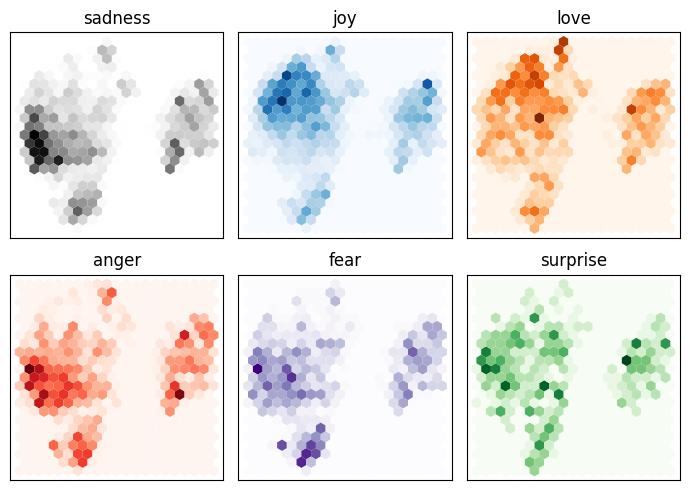

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(7,5))
axes = axes.flatten()
cmaps = ["Greys", "Blues", "Oranges", "Reds", "Purples", "Greens"]
labels = emotions["train"].features["label"].names

for i, (label, cmap) in enumerate(zip(labels, cmaps)):
    df_emb_sub = df_emb.query(f"label == {i}")
    axes[i].hexbin(df_emb_sub["X"], df_emb_sub["Y"], cmap=cmap,
                   gridsize=20, linewidths=(0,))
    axes[i].set_title(label)
    axes[i].set_xticks([]), axes[i].set_yticks([])

plt.tight_layout()
plt.show()

Pattern to read off: negative emotions (`sadness`, `anger`, `fear`) occupy overlapping
regions; `joy`/`love` sit apart and overlap each other; `surprise` is everywhere.
Prediction: confusions will follow these lines.

### A classical classifier on frozen features

Logistic regression on the 768-dim features — no GPU, seconds:

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(max_iter=3000)
lr_clf.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

In [ ]:
lr_clf.score(X_valid, y_valid)

0.634

~63% sounds unimpressive until the baseline. On an imbalanced set the honest floor is
"always predict the majority class":

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
dummy_clf.score(X_valid, y_valid)

0.352

~35% vs ~64% — the frozen encoder features carry real signal, with **zero gradient
steps through the model**. Where does it confuse things?

`plot_confusion_matrix` is defined here because we'll reuse it after fine-tuning:

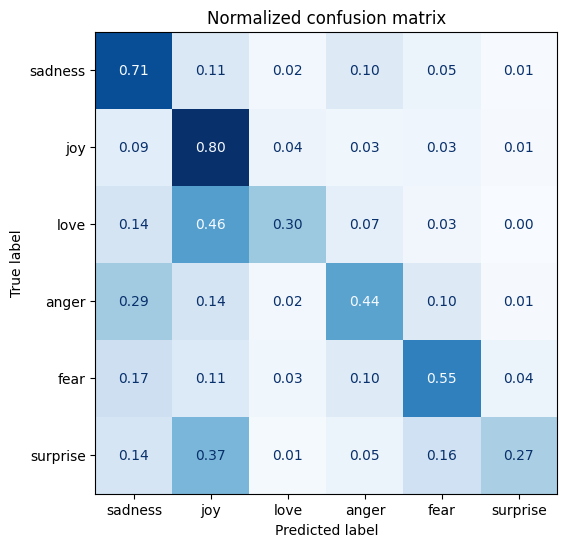

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_confusion_matrix(y_preds, y_true, labels):
    cm = confusion_matrix(y_true, y_preds, normalize="true")
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
    plt.title("Normalized confusion matrix")
    plt.show()

y_preds = lr_clf.predict(X_valid)
plot_confusion_matrix(y_preds, y_valid, labels)

Exactly as the UMAP plot suggested: `anger`/`fear` bleed into `sadness`; `love` and
`surprise` get mistaken for `joy`. Keep this matrix in mind — it's the bar that
fine-tuning has to clear.

---

## 4 · Fine-tuning end-to-end

Now train **everything**: swap the plain body for `AutoModelForSequenceClassification` —
the same DistilBERT plus a randomly initialized classification head
(`[768] → [num_labels]`). `num_labels=6` sizes the head; the head starts random, hence
the load warning about newly initialized weights.

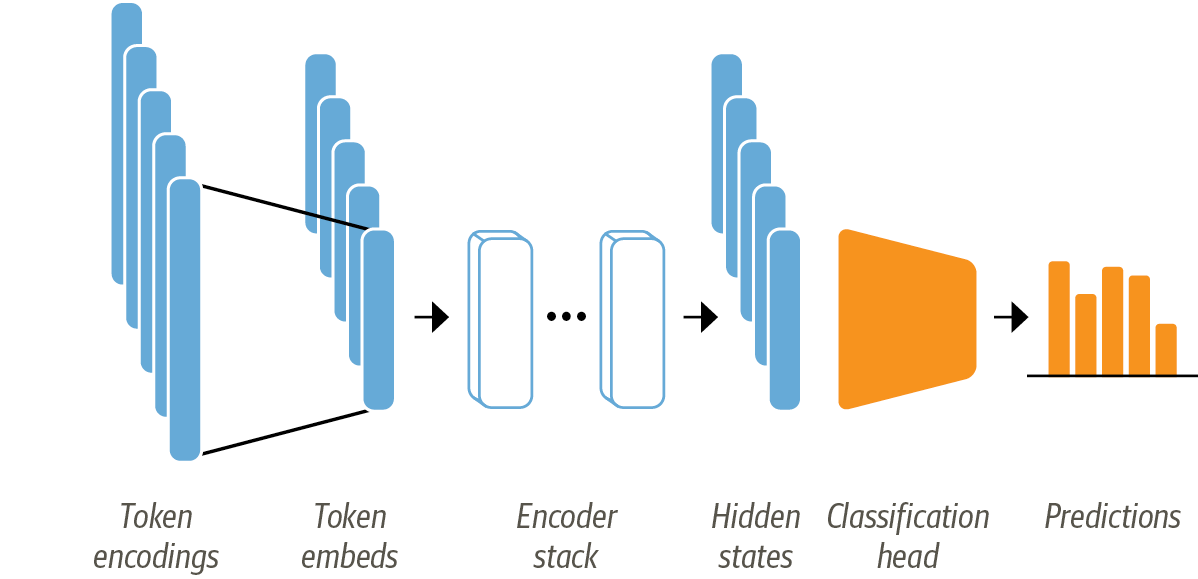

In [ ]:
from transformers import AutoModelForSequenceClassification

num_labels = 6
model = (AutoModelForSequenceClassification
         .from_pretrained(model_ckpt, num_labels=num_labels)
         .to(device))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Metrics hook for the `Trainer` — weighted F1 (weights = class frequency, the honest
choice for our imbalanced set) plus accuracy:

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

Hyperparameters via `TrainingArguments`. The load-bearing ones: `learning_rate=2e-5`
(fine-tuning uses ~100× smaller LRs than training from scratch — big steps destroy
pretrained features), `num_train_epochs=2` (fine-tuning overfits fast), batch 64.
`eval_strategy="epoch"` evaluates at the end of each epoch (v5 renamed it from
`evaluation_strategy`). Nothing is pushed to the Hub — everything stays local.
Log once per epoch (`logging_steps` = 16k/64):

In [ ]:
from transformers import Trainer, TrainingArguments

batch_size = 64
logging_steps = len(emotions_encoded["train"]) // batch_size
model_name = f"{model_ckpt}-finetuned-emotion"


training_args = TrainingArguments(output_dir=model_name,
                                  num_train_epochs=2,
                                  learning_rate=2e-5,
                                  per_device_train_batch_size=batch_size,
                                  per_device_eval_batch_size=batch_size,
                                  weight_decay=0.01,
                                  eval_strategy="epoch",
                                  disable_tqdm=False,
                                  logging_steps=logging_steps,
                                  log_level="error")

`Trainer` runs the loop: batching, device placement, optimizer/scheduler, evaluation.
`processing_class` (v5's renamed `tokenizer=`) makes it save the tokenizer alongside
every checkpoint — which is what lets us reload the model for inference later.
**This cell is the ~10-minute one on MPS** — watch eval `f1` climb past the ~63%
feature-extraction baseline:

In [ ]:
trainer = Trainer(model=model, args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset=emotions_encoded["train"],
                  eval_dataset=emotions_encoded["validation"],
                  processing_class=tokenizer)
trainer.train();

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.864065,0.350557,0.899000,0.897935
2,0.276433,0.242088,0.920000,0.919783


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Evaluation

`predict` runs the same pipeline on the validation split and returns raw logits +
metrics:

In [ ]:
preds_output = trainer.predict(emotions_encoded["validation"])

In [ ]:
preds_output.metrics

{'test_loss': 0.24208801984786987,
 'test_accuracy': 0.92,
 'test_f1': 0.9197830453579766,
 'test_runtime': 4.2391,
 'test_samples_per_second': 471.796,
 'test_steps_per_second': 7.549}

Greedy-decode the logits, then the moment of truth — same confusion-matrix function as
before, now on fine-tuned predictions:

In [ ]:
y_preds = np.argmax(preds_output.predictions, axis=1)

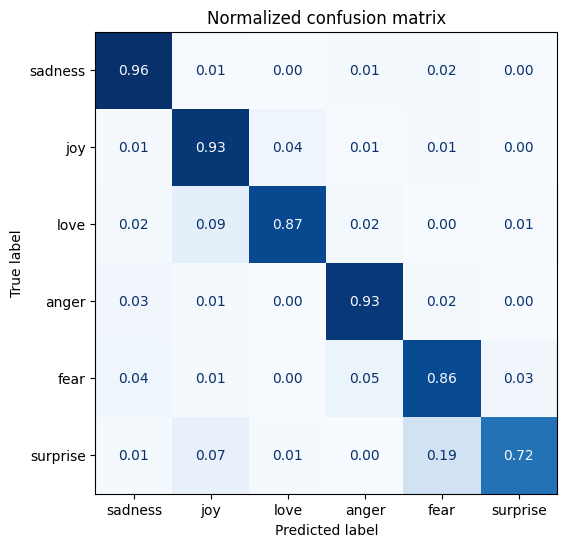

In [ ]:
plot_confusion_matrix(y_preds, y_valid, labels)

Much closer to a diagonal. `love`→`joy` confusion persists (arguably a labeling
philosophy problem, not a model problem). Weighted F1 ≈ 92% vs the ~63% of frozen
features — the price was gradients through all 66M parameters. That ladder — frozen
body / partial fine-tune / full fine-tune — is exactly the design space of
Assignment 2.

---

## 5 · Error analysis

Accuracy numbers hide *which* examples fail. Sort the validation set by per-example
loss: high loss = wrong & confident, low loss = right & confident. Both ends are worth
reading — the first for mislabels, the second for shortcut features the model exploits.
Forward pass with per-sample loss (no `reduction="mean"` this time):

In [ ]:
from torch.nn.functional import cross_entropy

def forward_pass_with_label(batch):
    # Place all input tensors on the same device as the model
    inputs = {k:v.to(device) for k,v in batch.items()
              if k in tokenizer.model_input_names}

    with torch.no_grad():
        output = model(**inputs)
        pred_label = torch.argmax(output.logits, axis=-1)
        loss = cross_entropy(output.logits, batch["label"].to(device),
                             reduction="none")

    # Place outputs on CPU for compatibility with other dataset columns
    return {"loss": loss.cpu().numpy(),
            "predicted_label": pred_label.cpu().numpy()}

In [ ]:
emotions_encoded.set_format("torch",
                            columns=["input_ids", "attention_mask", "label"])
# Compute loss values
emotions_encoded["validation"] = emotions_encoded["validation"].map(
    forward_pass_with_label, batched=True, batch_size=16)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
emotions_encoded.set_format("pandas")
cols = ["text", "label", "predicted_label", "loss"]
df_test = emotions_encoded["validation"][:][cols]
df_test["label"] = df_test["label"].apply(label_int2str)
df_test["predicted_label"] = (df_test["predicted_label"]
                              .apply(label_int2str))

**Highest loss first** — read these as an annotator would: genuine model failure, or
wrong gold label?

In [ ]:
df_test.sort_values("loss", ascending=False).head(10)

,text,label,predicted_label,loss
882,i feel badly about reneging on my commitment t...,love,sadness,5.658702
1950,i as representative of everything thats wrong ...,surprise,sadness,5.641178
1801,i feel that he was being overshadowed by the s...,love,sadness,5.501508
1963,i called myself pro life and voted for perry w...,joy,sadness,5.399712
1870,i guess i feel betrayed because i admired him ...,joy,sadness,5.287922
1509,i guess this is a memoir so it feels like that...,joy,fear,4.943048
465,i would eventually go in to these stores but i...,joy,fear,4.933452
1274,i am going to several holiday parties and i ca...,joy,sadness,4.855948
1662,i did not directly react to the spot fixing co...,joy,anger,4.695118
1500,i guess we would naturally feel a sense of lon...,anger,sadness,4.652871


**Lowest loss** — the model's most confident cases. Check it isn't riding a shortcut
(e.g. the literal word "sad"): if it is, it will fail exactly where the shortcut is
absent:

In [ ]:
df_test.sort_values("loss", ascending=True).head(10)

,text,label,predicted_label,loss
1861,im tired of feeling lethargic hating to work o...,sadness,sadness,0.020824
1140,i do think about certain people i feel a bit d...,sadness,sadness,0.021273
244,im kinda relieve but at the same time i feel d...,sadness,sadness,0.021504
189,i leave the meeting feeling more than a little...,sadness,sadness,0.021845
1368,i started this blog with pure intentions i mus...,sadness,sadness,0.021902
1466,i feel so ungrateful to be wishing this pregna...,sadness,sadness,0.021986
1502,i feel ungrateful for stupid shit like,sadness,sadness,0.022026
1452,i always feel guilty and come to one conclusio...,sadness,sadness,0.022118
392,i remember feeling disheartened one day when w...,sadness,sadness,0.022155
69,i have no extra money im worried all of the ti...,sadness,sadness,0.022169


Typical findings: some `joy` rows are mislabeled by the dataset's own annotation
process; the most confident predictions are usually `sadness`. Cleaning even a few
hundred labels often buys more F1 than a bigger model — data-centric AI in one cell.

---

## 6 · Saving the model & running inference locally

`checkpoint-500` is the raw training artifact — weights **plus** optimizer/scheduler
state for resuming. For deployment we save a clean directory: weights + config +
tokenizer, nothing else.

One catch worth knowing: the head was created with generic names, so the saved config
says `LABEL_0 … LABEL_5`. We patch `id2label`/`label2id` from the dataset's
`ClassLabel` before saving — otherwise every inference result says "LABEL_1" instead
of "joy" ("transformers" v5 does *not* propagate dataset label names, and ignores
`id2label=` passed to `pipeline()`):

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

ckpt = "distilbert-base-uncased-finetuned-emotion/checkpoint-500"
final_dir = "distilbert-base-uncased-finetuned-emotion-final"

model = AutoModelForSequenceClassification.from_pretrained(ckpt)
model.config.id2label = dict(enumerate(emotions["train"].features["label"].names))
model.config.label2id = {name: i for i, name in enumerate(emotions["train"].features["label"].names)}
model.save_pretrained(final_dir)
AutoTokenizer.from_pretrained(ckpt).save_pretrained(final_dir)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('distilbert-base-uncased-finetuned-emotion-final/tokenizer_config.json',
 'distilbert-base-uncased-finetuned-emotion-final/tokenizer.json')

Now the Demo-1 loop closes: `pipeline` again, but pointed at **our** local directory.
Unlike `Trainer`, `pipeline` does *not* auto-detect MPS — set `device="mps"`
(CUDA users: `device=0`).

In [ ]:
from transformers import pipeline

classifier = pipeline("text-classification",
                      model="distilbert-base-uncased-finetuned-emotion-final",
                      device=device)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

One tweet the model has never seen. `top_k=None` returns **all six** probabilities —
and in v5 that list is *sorted by score*, not by class index, so we re-align to the
dataset's class order before plotting:

In [ ]:
custom_tweet = "I saw a movie today and it was really good."
preds = classifier(custom_tweet, top_k=None)
labels = emotions["train"].features["label"].names

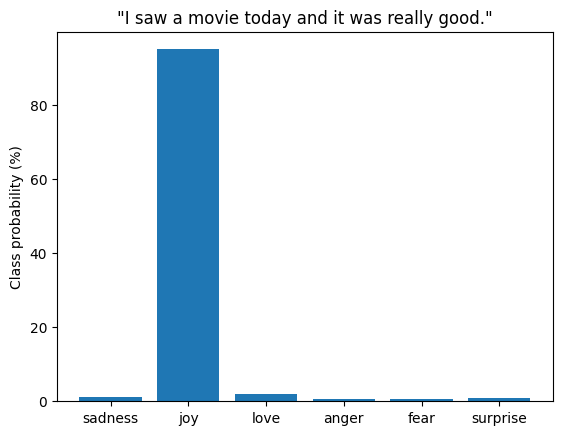

In [ ]:
preds_df = (pd.DataFrame(preds)
            .set_index("label")
            .loc[labels]        # re-align: v5 sorts top_k=None output by score
            .reset_index())
plt.bar(preds_df["label"], 100 * preds_df["score"], color='C0')
plt.title(f'"{custom_tweet}"')
plt.ylabel("Class probability (%)")
plt.show()

## Wrap-up

You trained a transformer classifier end-to-end and deployed it from a local folder.
The three ideas that matter for Assignment 2:

1. **The ladder of effort.** Frozen features (§3, ~64% accuracy) → full fine-tuning
   (§4, ~92% weighted F1). Assignment 2 forbids full fine-tuning: you'll climb the two rungs we
   skipped — **linear head only** (body frozen, ~1.5K trainable params) and **partial
   fine-tuning** (head + top layers).
2. **The head decides the shape.** Sequence classification pools `[CLS]` → linear.
   Token tasks (NER, POS) predict per-token. Span QA predicts start/end. Same body,
   different head — you'll swap between families.
3. **Evaluation discipline.** Baseline first (dummy classifier), imbalanced-set metrics
   (weighted F1, not accuracy), and error analysis by loss before believing the number.